# Pytorch Computer Vision

In [4]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.9.0+cu126
0.24.0+cu126


## 1. Getting a dataset

In [5]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.6MB/s]


In [6]:
len(train_data), len(test_data)

(60000, 10000)

In [7]:
# See the first training example
image, label = train_data[5]
image[:,10], label

(tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.7961, 0.7765, 0.6745, 0.7176, 0.8078,
          1.0000, 1.0000, 0.9804, 0.9529, 0.9412, 0.9373, 0.9216, 0.9333, 0.9569,
          1.0000, 0.9333, 0.7216, 0.6275, 0.3373, 0.3843, 0.0000, 0.0000, 0.0000,
          0.0000]]),
 2)

In [8]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [9]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [10]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [11]:
image.shape

torch.Size([1, 28, 28])

### 1.2 Visualizing our data

Image shape is: torch.Size([1, 28, 28])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

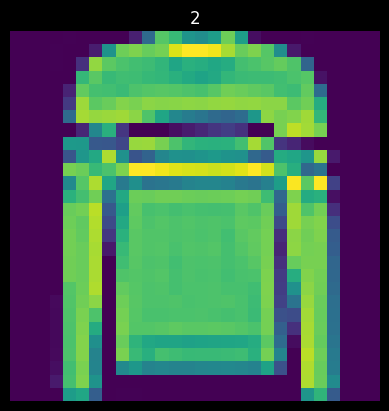

In [12]:
import matplotlib.pyplot  as plt
image, label = train_data[5]
print(f"Image shape is: {image.shape}")
plt.style.use('dark_background')
plt.imshow(image.squeeze())
plt.title(label)
plt.axis(False)

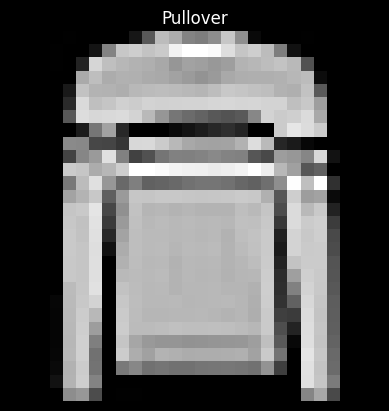

In [13]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(class_name[label])
plt.axis(False)
plt.show()

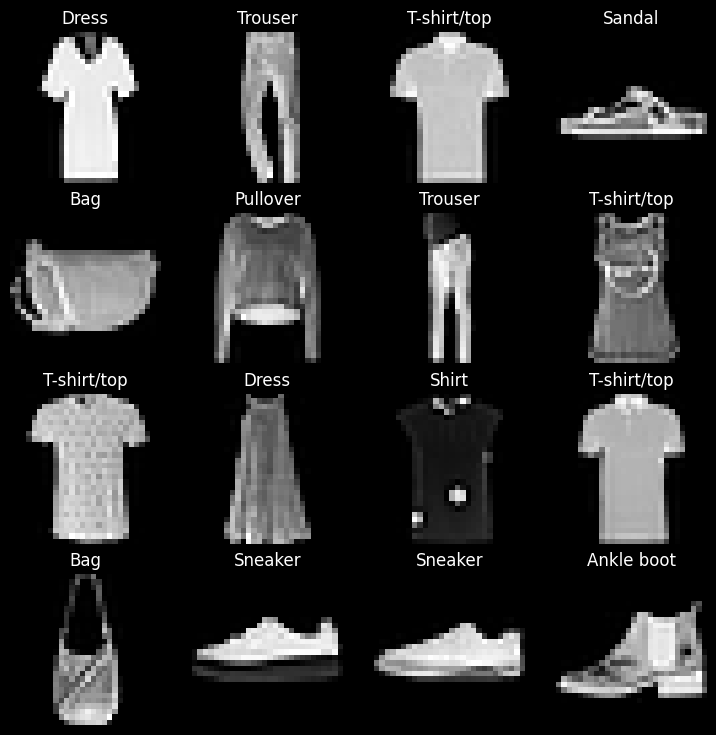

In [14]:
# Pot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
row, cols = 4, 4
for i in range(1, row*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(row, cols, i)
  plt.imshow(img.squeeze(), cmap='gray')
  plt.title(class_name[label])
  plt.axis(False)

In [15]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader

In [16]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a53242d9490>,
 <torch.utils.data.dataloader.DataLoader at 0x7a53241c2f30>)

In [17]:
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader: {len(test_dataloader)} batch of {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7a53242d9490>, <torch.utils.data.dataloader.DataLoader object at 0x7a53241c2f30>)
Length of train_dataloader: 1875 batches of 32...
Length of test_dataloader: 313 batch of 32...


In [18]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 8, label size: torch.Size([])


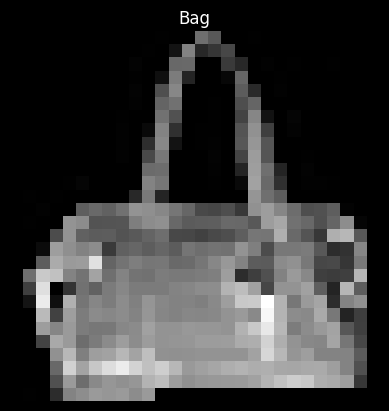

In [19]:
# Show a ample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_name[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")


## 3. Model 0: Build a basline model

In [20]:
 # Create a flatten layer
flatten_model = nn.Flatten()

x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x)

print(f"shape before flattening: {x.shape}")
print(f"shape after flattening: {output.shape}")

shape before flattening: torch.Size([1, 28, 28])
shape after flattening: torch.Size([1, 784])


In [21]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )
  def forward(self, x):
    return self.layer_stack(x)

In [22]:
torch.manual_seed(42)

# Setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_name)).to()
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [23]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [24]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loos, optimizer and evaluation metrics

In [25]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path('helper_functions.py').is_file():
  print('helper_functions.py already exists, skipping download')
else:
  print("Downloading helper_function.py")
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)

In [26]:
# Import accuracy metric
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

### 3.2 Creating a function to time our experiment

In [27]:
from timeit import default_timer as timer
def print_train_time(start:float,
                     end:float,
                     device:torch.device=None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [28]:
start_time = timer()
# some code...
end_time = timer()
print_train_time(start=start_time, end=end_time, device="cpu")

Train time on cpu: 0.000 seconds


2.8535999945233925e-05

 ### 3.3 Creating a training loop

In [29]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and atart the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs
epochs = 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  ### Training
  train_loss = 0
  # Add a loop to loop through the training batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calculate loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Print out
    if batch % 400 == 0:
      print(f"Look at {batch * len(X)} / {len(train_dataloader.dataset)} samples.")

  train_loss /= len(train_dataloader)


  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      test_pred = model_0(X_test)

      test_loss += loss_fn(test_pred, y_test)
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))





  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Look at 0 / 60000 samples.
Look at 12800 / 60000 samples.
Look at 25600 / 60000 samples.
Look at 38400 / 60000 samples.
Look at 51200 / 60000 samples.

Train loss: 0.5904 | Test loss: 0.5095 | Test accuracy: 82.0387
Epoch: 1
-----
Look at 0 / 60000 samples.
Look at 12800 / 60000 samples.
Look at 25600 / 60000 samples.
Look at 38400 / 60000 samples.
Look at 51200 / 60000 samples.

Train loss: 0.4763 | Test loss: 0.4799 | Test accuracy: 83.1969
Epoch: 2
-----
Look at 0 / 60000 samples.
Look at 12800 / 60000 samples.
Look at 25600 / 60000 samples.
Look at 38400 / 60000 samples.
Look at 51200 / 60000 samples.

Train loss: 0.4550 | Test loss: 0.4766 | Test accuracy: 83.4265
Train time on cpu: 26.112 seconds


## 4. Make predictions and get Model 0 results

In [30]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """Retruns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      y_pred = model_0(X)

      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

      # Scaling the loss and accuracy
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}



In [31]:
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## 5. Setup device ignostic-code

In [32]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building a better model with non-linearity

In [33]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input: int,
               hidden: int,
               output: int):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input,
                  out_features=hidden),
        nn.ReLU(),
        nn.Linear(in_features=hidden,
                  out_features=output),
        nn.ReLU(),
    )
  def forward(self, x: torch.Tensor):
    return self.layers(x)


In [34]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input=784,
                              hidden=10,
                              output=len(class_name)).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss function & optimizer

In [35]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)


### 6.2 Functionazing training and evaluation/testing loops

In [36]:
def train_step(model: torch.nn.Module,
                 data_loader: torch.utils.data.DataLoader,
                 loss_fn: torch.nn.Module,
                 optimizer : torch.optim.Optimizer,
                 accuracy_fn,
                 device: torch.device=device):
  """Performs a training with model trying to learn on data_loader"""
  ### Training
  train_loss, train_acc = 0, 0

  # Put model into training mode
  model.train()

  # Add loop to loop through the training batches
  for batch, (X, y) in enumerate(data_loader):
    # Put data on the target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate loss & accuracy
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()


  # Divide total train loss and accuracy by lenght of train dataloader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  # Print out what's happening
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

In [37]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device:torch.device=device):
  """Performing a testing loop step on model going over data_loader."""
  test_accuracy, test_loss = 0, 0
  # Put the model in eval mode
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)

      # Forward pass
      y_pred = model(X)

      # Calculate the loss & accuracy
      test_loss += loss_fn(y_pred, y)
      test_accuracy += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    # Adjust metrics and print out
    test_loss /= len(data_loader)
    test_accuracy /= len(data_loader)

    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_accuracy:.2f}%\n")


In [38]:
torch.manual_seed(42)
from timeit import default_timer as Timer
train_time_start_on_gpu = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             optimizer=optimizer,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
             device=device
             )
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device
            )
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Train loss: 1.09199 | Train accuracy: 61.34%
Test loss: 0.95636 | Test accuracy: 65.00%

Epoch: 1
------
Train loss: 0.78101 | Train accuracy: 71.93%
Test loss: 0.72227 | Test accuracy: 73.91%

Epoch: 2
------
Train loss: 0.67027 | Train accuracy: 75.94%
Test loss: 0.68500 | Test accuracy: 75.02%

Train time on None: 29.488 seconds


In [39]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
  """Retruns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

      # Scaling the loss and accuracy
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}


In [40]:
# Get model_1 result dictionary
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results


  0%|          | 0/313 [00:00<?, ?it/s]

{'model': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [41]:
model_0_results

{'model': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## Model 2: Building a Convolutional Neural Network(CNN)

In [42]:
# Create a convoutional neural network
class FashionMNISTModelV2(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_shape: int,
               output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_shape,
                  out_channels=hidden_shape,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_shape * 7 * 7,
                  out_features=output_shape),
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    return x


In [43]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, hidden_shape=10, output_shape=len(class_name))

### 7.1 Stepping through `nn.Conv2d()`

In [44]:
torch.manual_seed(42)

# Create a batch of images
images = torch.rand(32, 3, 64, 64)
test_image = images[0]
test_image.shape

torch.Size([3, 64, 64])

In [45]:
conv_layer = nn.Conv2d(in_channels=3,
                    out_channels=10,
                    kernel_size=(3, 3),
                    stride=1,
                    padding=0)

conv_output = conv_layer(test_image.unsqueeze(0))
conv_output.shape

torch.Size([1, 10, 62, 62])

### 7.2 Stepping through `nn.MaxPool2d()`

In [46]:
max_pool = nn.MaxPool2d(kernel_size=2)
max_output = max_pool(conv_output)
max_output.shape

torch.Size([1, 10, 31, 31])

In [47]:
# Creating a random tensor
torch.manual_seed(42)

random_tensor = torch.rand(1, 1, 2, 2)
max_pool_layer = nn.MaxPool2d(kernel_size=2)
out_put = max_pool_layer(random_tensor)
out_put

tensor([[[[0.9593]]]])

In [48]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_shape=10,
                              output_shape=len(class_name)).to(device)

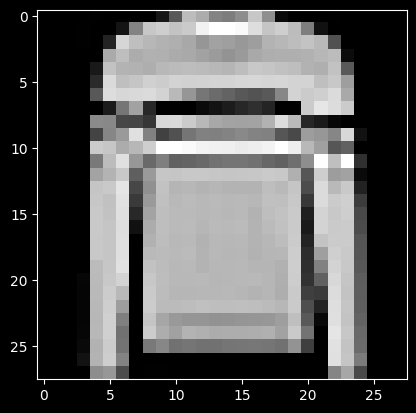

In [49]:
plt.imshow(image.squeeze(), cmap="gray")

In [50]:
rand_image_tensor = torch.rand(1, 28, 28)

In [51]:
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0372, -0.0748,  0.0573, -0.0396, -0.0098,  0.0194, -0.0003, -0.0114,
          0.0206,  0.0003]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3 Setup a loss function and optimizer

In [52]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

### 7.4 Train & test model_2

In [53]:
torch.manual_seed(42)
epochs = 3

from timeit import default_timer as timer
timer_start = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch} --------\n")
    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    test_step(model=model_2,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

timer_end = timer()
total_time_spend_model_2 = print_train_time(start=timer_start,
                                            end=timer_end,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0 --------

Train loss: 0.59133 | Train accuracy: 78.58%
Test loss: 0.40056 | Test accuracy: 85.69%

Epoch: 1 --------

Train loss: 0.36211 | Train accuracy: 86.87%
Test loss: 0.34977 | Test accuracy: 87.35%

Epoch: 2 --------

Train loss: 0.32158 | Train accuracy: 88.33%
Test loss: 0.32126 | Test accuracy: 88.41%

Train time on cuda: 35.079 seconds


In [54]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model': 'FashionMNISTModelV2',
 'model_loss': 0.3212634325027466,
 'model_acc': 88.40854632587859}

## 8. Compare models results with each other

In [55]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
compare_results

,model,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.321263,88.408546


In [56]:
# Add training time to results
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_time_spend_model_2]

compare_results


,model,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,26.112360
1,FashionMNISTModelV1,0.685001,75.019968,29.487635
2,FashionMNISTModelV2,0.321263,88.408546,35.078710


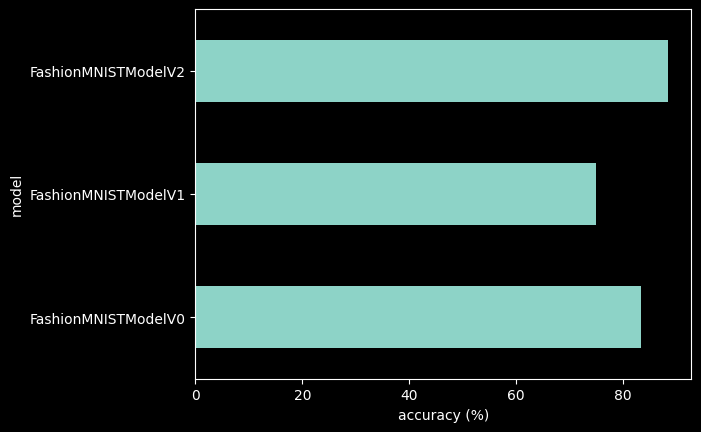

In [57]:
# Visualize the results
compare_results.set_index("model")['model_acc'].plot(kind='barh')
plt.xlabel('accuracy (%)')
plt.ylabel('model');

## 9. Make and evaluate random prediction with best model

In [58]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)
      pred_logits = model(sample)
      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [59]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Coat')

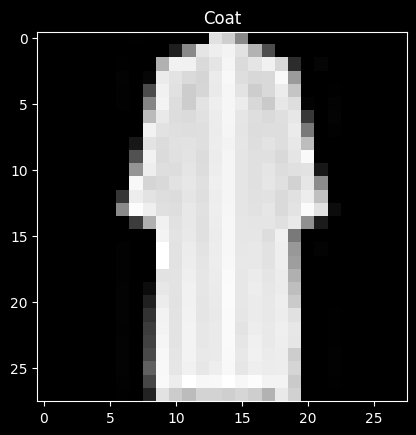

In [60]:
plt.imshow(test_samples[0].squeeze(), cmap='gray')
plt.title(class_name[test_labels[0]])

In [61]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

pred_probs[:2]

tensor([[1.1178e-02, 1.9301e-03, 2.2327e-03, 6.8197e-01, 2.8741e-01, 1.9978e-06,
         3.4703e-03, 1.7436e-04, 1.1625e-02, 4.2836e-06],
        [5.1300e-08, 5.6652e-10, 3.2793e-08, 1.4415e-09, 4.4871e-10, 1.0000e+00,
         3.9294e-08, 1.8487e-08, 3.9398e-06, 1.8763e-07]])

In [62]:
# Convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([3, 5, 2, 6, 9, 2, 0, 0, 8])

In [63]:
test_labels

[4, 5, 2, 4, 9, 2, 0, 6, 6]

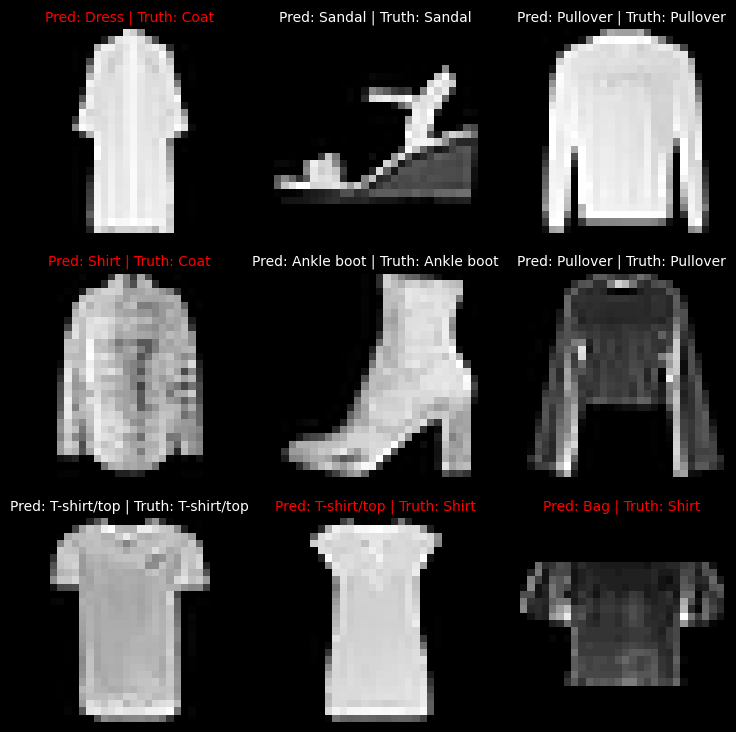

In [64]:
plt.figure(figsize=(9, 9))
nrow = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrow, ncols, i+1)

  # Plot target image
  plt.imshow(sample.squeeze(), cmap='gray')

  # Find the prediction
  pred_label = class_name[pred_classes[i]]
  truth_label = class_name[test_labels[i]]

  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c='w')
  else:
    plt.title(title_text, fontsize=10, c='r')
  plt.axis(False)


## 10. Making a confusion matrix

In [68]:
from tqdm.auto import tqdm

y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc='Making predictions...'):
    X, y = X.to(device), y.to(device)

    y_logits = model_2(X)

    y_pred = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim=1)

    y_preds.append(y_pred.cpu())

  # print(y_preds)
  y_pred_tensor = torch.cat(y_preds)
  y_pred_tensor

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

In [69]:
y_pred_tensor

tensor([9, 2, 1,  ..., 8, 1, 8])

In [74]:
!pip install torchmetrics

In [75]:
import torchmetrics, mlxtend

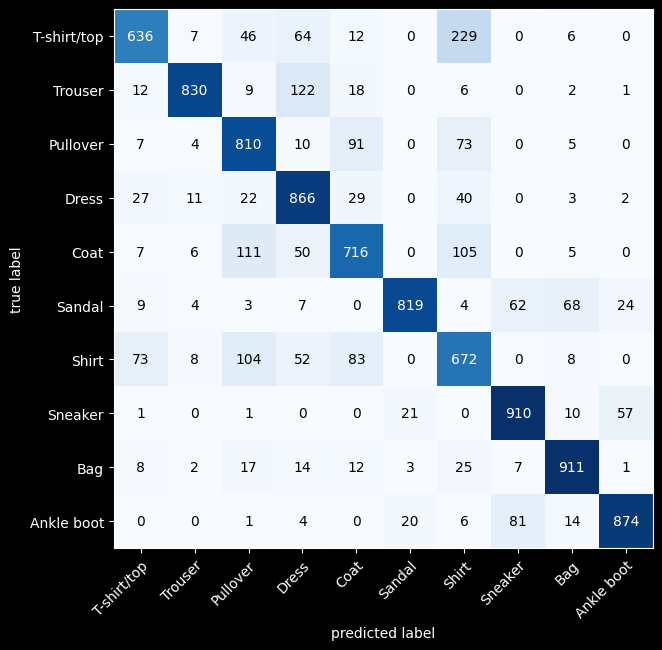

In [83]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(class_name), task='MULTICLASS')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# Plot cofusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_name,
    figsize=(10, 7)
)

## 11. Save and load best performing model

In [85]:
from pathlib import Path

MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# Create mode save
MODEL_NAME = "pytorch_computer_vision_model_2.pth"
MODEL_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model_2.state_dict(),
           f=MODEL_PATH)


In [87]:
# Create a new instence
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_shape=10,
                                     output_shape=len(class_name))

loaded_model_2.load_state_dict(torch.load(f=MODEL_PATH))

loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [88]:
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn=accuracy_fn
)

  0%|          | 0/313 [00:00<?, ?it/s]

In [89]:
loaded_model_2_results

{'model': 'FashionMNISTModelV2',
 'model_loss': 0.3212634325027466,
 'model_acc': 88.40854632587859}

In [91]:
model_2_results

{'model': 'FashionMNISTModelV2',
 'model_loss': 0.3212634325027466,
 'model_acc': 88.40854632587859}

In [98]:
torch.isclose(torch.tensor(model_2_results['model_loss']),
              torch.tensor(loaded_model_2_results['model_loss']),
              atol=1e-02)

tensor(True)